The purpose of this notebook is to test how well the power spectrum can constrain the longest timescale noise forcing using the fit of the power spectrum on the highest frequencies.

Notebook will first simulate absurdly long timescale forcings

Then will look at the spectral windows

In [ ]:
from hydra import compose, initialize
import matplotlib.pyplot as plt
import xarray as xr
import numpy as np
from pathlib import Path
from astropy.timeseries import LombScargle
from methane_noise_forcing import io
from methane_noise_forcing import detrend_obs, calculate_mean_and_ci
from methane_noise_forcing.core import sample_ensemble_series, FirnFilter
from methane_noise_forcing.noise import simulate_two_timescale_ar1

plt.rcParams.update({
    "font.size": 7,
})

In [2]:
## figure settings
fig_width = 3.42 # inches, aim for single column

colors = {
    "obs": "k",
    "red_noise": "tab:blue",
    "red_noise_filtered": "tab:orange"
}
alphas = {
    "red_noise": 0.15,
    "red_noise_filtered": 0.2
}

In [3]:
# choose smoothing filter and sampling location
site_name = "wdc06a" # wdc05a, wdc06a, gisp2, or neem
if site_name == "wdc05a" or site_name == "wdc06a":
    filter_name = "wais"
else:
    filter_name = site_name

with initialize(version_base=None, config_path="../configs"):
    cfg = compose(config_name="config", overrides=[
        # f"+noise=white_noise_ar1",
        f"+noise=two_timescale_ar1_100",
        f"+firn_kernel=firn_model_{filter_name}",
        f"+sampling={site_name}"
    ])

# load observations and psd

In [4]:
## obs and detrending
data_obs = io.load_observational_data(site_name, **cfg.io[site_name].input)
# detrend data
data_obs_detrended = detrend_obs(site_name, data_obs)
# convert to dataset with 'ch4' and 'ch4_detrended'
data_obs = xr.Dataset(
    {
        "ch4": (["time"], data_obs.ch4),
        "ch4_detrended": (["time"], data_obs_detrended.ch4),
    },
    coords={
        "time": data_obs.gas_age
    }
)
# invert time axis
data_obs = data_obs.isel(time=slice(None, None, -1))

## power spectrum
psd_obs = xr.open_dataset(cfg.io[site_name].power_spectra_path)

2025-08-25 14:31:38,516 - methane_noise_forcing.io - INFO - Loading WDC06A data from /home/disk/p/emei/repos/methane_noise_forcing/data/observations/cultivated/mitchelletal2013_wdc06a.csv
2025-08-25 14:31:38,525 - methane_noise_forcing.utils - INFO - Detrending data with polynomial of order 2


Text(0.5, 0, 'Time (year CE)')

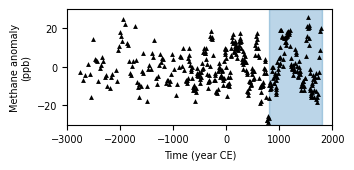

In [5]:
## plot panel A, which is a timeseries of the obs
ylim = (-30, 30)
xlim = (-3000, 2000)
time_shading = (800, 1800)

fig, ax = plt.subplots(figsize=(fig_width, 1.5))

ax.plot(
    data_obs.time,
    data_obs["ch4_detrended"],
    color=colors["obs"],
    marker='^',
    markersize=3.5,
    markeredgecolor="None",
    linestyle="None",
)
# add shading for period in figure 2
ax.axvspan(*time_shading, color="tab:blue", alpha=0.3)

ax.set_ylim(ylim)
ax.set_xlim(xlim)
ax.set_ylabel("Methane anomaly\n(ppb)")
ax.set_xlabel("Time (year CE)")

## generate noise and calculate psd

In [74]:
## generate raw and smoothed noise
# parameters
tau_ch4 = 10 # years
tau_forcing = 1 # years
variance_x = np.var(data_obs.ch4_detrended, ddof=1).values.item()
dt = 1 # years
duration_timeseries = 4750
n_ens = 1000
n_steps = int(duration_timeseries / dt)

# generate raw noise
noise_raw, _ = simulate_two_timescale_ar1(
    n_ens=n_ens,
    n_steps=n_steps,
    dt=dt,
    tau_x=tau_ch4,
    tau_eta=tau_forcing,
    variance_x=variance_x
)
# put into dataset
noise_raw = xr.Dataset(
    {
        "ch4": (["ensemble", "time"], noise_raw),
    },
    coords={
        "ensemble": np.arange(n_ens),
        "time": np.arange(n_steps) * dt,
    },
)

# load firn filter
firn_filter = FirnFilter.fit_from_config(
    kernel_type=cfg.firn_kernel.type,
    parameters=cfg.firn_kernel.parameters,
    path_root=cfg.paths.firn_filters_root
)
# apply filter to noise
noise_smoothed = []
for idx_ens in noise_raw.ensemble.values:
    noise_smoothed.append(
        firn_filter.apply(
            noise_raw["ch4"].isel(ensemble=idx_ens).values, dt_series=cfg.noise.dt
        )
    )
# put into dataset
noise_smoothed = xr.Dataset(
    {
        "ch4": (("ensemble", "time"), np.array(noise_smoothed))
    },
    coords={
        "ensemble": noise_raw.ensemble.values,
        "time": noise_raw.time.values
    }
)

In [30]:
## sample at same points as obs
noise_raw_sampled = sample_ensemble_series(
    da=noise_raw["ch4"],
    core_time=data_obs.time,
    core_offset_flag="start",
    series_offset=150
)
noise_smoothed_sampled = sample_ensemble_series(
    da=noise_smoothed["ch4"],
    core_time=data_obs.time,
    core_offset_flag="start",
    series_offset=150
)

# scale by ensemble mean variance
var_obs = np.var(data_obs["ch4_detrended"], ddof=1)
var_raw_sampled = noise_raw_sampled.var(ddof=1, dim="time")
var_smoothed_sampled = noise_smoothed_sampled.var(ddof=1, dim="time")
print(f"Observed variance: {var_obs:0.1f} ppb^2")
print(f"Raw sampled variance: {var_raw_sampled.mean():0.1f} ± {var_raw_sampled.std():0.1f} ppb^2")
print(f"Smoothed sampled variance: {var_smoothed_sampled.mean():0.1f} ± {var_smoothed_sampled.std():0.1f} ppb^2")
noise_raw_sampled *= np.sqrt(var_obs/var_raw_sampled.mean())
noise_smoothed_sampled *= np.sqrt(var_obs/var_smoothed_sampled.mean())

## calculate psd
psd_raw = []
psd_smooth = []
for idx_ens in noise_raw_sampled.ensemble.values:
    # red noise raw
    frequencies, power_spectrum = LombScargle(
        noise_raw_sampled.time.values, 
        noise_raw_sampled.sel(ensemble=idx_ens).values
        ).autopower(
            normalization="psd", 
            samples_per_peak=1,
    )
    psd_raw.append(power_spectrum)

    # red noise smoothed
    frequencies, power_spectrum = LombScargle(
        noise_smoothed_sampled.time.values, 
        noise_smoothed_sampled.sel(ensemble=idx_ens).values
        ).autopower(
            normalization="psd", 
            samples_per_peak=1,
    )
    psd_smooth.append(power_spectrum)

# combine into dataset
psd_noise_sampled = xr.Dataset(
    {
        "red_noise": (["ensemble", "frequency"], np.array(psd_raw)),
        "red_noise_filtered": (["ensemble", "frequency"], np.array(psd_smooth)),
    },
    coords={
        "frequency": frequencies,
        "ensemble": noise_raw_sampled.ensemble.values,
    }
)

Observed variance: 103.3 ppb^2
Raw sampled variance: 98.0 ± 24.7 ppb^2
Smoothed sampled variance: 89.9 ± 24.4 ppb^2


[Text(0, 0.1, '0.1'),
 Text(0, 1.0, '1'),
 Text(0, 10.0, '10'),
 Text(0, 100.0, '100'),
 Text(0, 1000.0, '1000')]

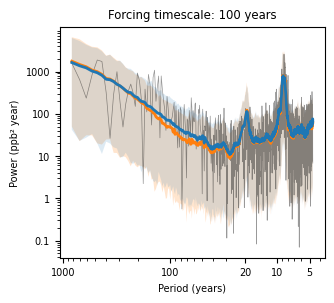

In [31]:
## plot psd
# upper bound mask
period_high = 1000
tick_labels = [1000, 100, 20, 10, 5]
mask = frequencies >= 1/period_high
frequencies_to_plot = frequencies[mask]

fig, ax = plt.subplots(figsize=(fig_width, 3))

# observed
ax.plot(
    1 / psd_obs.sel(frequency=frequencies_to_plot).frequency,
    psd_obs.sel(frequency=frequencies_to_plot).power_spectrum_detrended_unnormalized,
    color=colors["obs"],
    linewidth=0.5,
    alpha=0.4
)
# plot mean and confidence intervals for sampled noise
for key in ["red_noise_filtered", "red_noise"]:
    mean, ci_low, ci_high = calculate_mean_and_ci(psd_noise_sampled.sel(frequency=frequencies_to_plot)[key])
    ax.plot(
        1 / psd_noise_sampled.sel(frequency=frequencies_to_plot).frequency,
        mean,
        color=colors[key],
        linewidth=2
    )
    ax.fill_between(
        1 / psd_noise_sampled.sel(frequency=frequencies_to_plot).frequency,
        ci_low,
        ci_high,
        color=colors[key],
        alpha=alphas[key],
        edgecolor="none"
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb² year)")
ax.set_xticks(tick_labels)
ax.set_xticklabels([f"{tick}" for tick in tick_labels])
ax.set_title(f"Forcing timescale: {tau_forcing} years")

# set y-axis ticks to plain numbers
y_tick_labels = [0.1, 1, 10, 100, 1000]
ax.set_yticks(y_tick_labels)
ax.set_yticklabels([str(y) for y in y_tick_labels])

# check if spectral window is causing issues
It's a mystery to me why increasing the timescale of the forcing leads to a better (over)fit at the high frequencies. My intuition is that a longer timescale of forcing should lead to power at high frequencies that is too low. Below, check that the power spectrum of the unsampled AR(1) both smoothed and unsmoothed behaves as expected.

In [75]:
## calculate psd
# parameters
n_ens_psd = 200

# calculate ensemble variance for scaling:
var_raw = noise_raw.var(ddof=1, dim="time")
var_smoothed = noise_smoothed.var(ddof=1, dim="time")
noise_raw_scaled = noise_raw * np.sqrt(var_obs/var_raw.mean())
noise_smoothed_scaled = noise_smoothed * np.sqrt(var_obs/var_smoothed.mean())

psd_raw = []
psd_smooth = []
for idx_ens in np.arange(n_ens_psd):
    # red noise raw
    frequencies, power_spectrum = LombScargle(
        noise_raw_scaled.time.values, 
        noise_raw_scaled["ch4"].sel(ensemble=idx_ens).values
        ).autopower(
            normalization="psd", 
            samples_per_peak=1,
    )
    psd_raw.append(power_spectrum)

    # red noise smoothed
    frequencies, power_spectrum = LombScargle(
        noise_smoothed_scaled.time.values, 
        noise_smoothed_scaled["ch4"].sel(ensemble=idx_ens).values
        ).autopower(
            normalization="psd", 
            samples_per_peak=1,
    )
    psd_smooth.append(power_spectrum)

# combine into dataset
psd_noise = xr.Dataset(
    {
        "red_noise": (["ensemble", "frequency"], np.array(psd_raw)),
        "red_noise_filtered": (["ensemble", "frequency"], np.array(psd_smooth)),
    },
    coords={
        "frequency": frequencies,
        "ensemble": np.arange(n_ens_psd),
    }
)

(1e-05, 100000.0)

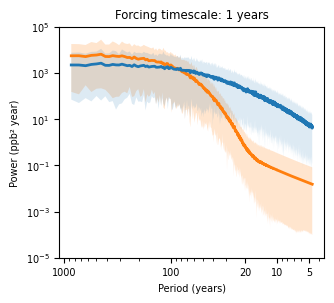

In [76]:
## plot psd
# upper bound mask
period_high = 1000
period_low = 4.67
ylim = (1e-5, 1e5)
tick_labels = [1000, 100, 20, 10, 5]
mask = (frequencies >= 1/period_high) & (frequencies <= 1/period_low)
frequencies_to_plot = frequencies[mask]

fig, ax = plt.subplots(figsize=(fig_width, 3))

# plot mean and confidence intervals for sampled noise
for key in ["red_noise_filtered", "red_noise"]:
    mean, ci_low, ci_high = calculate_mean_and_ci(psd_noise.sel(frequency=frequencies_to_plot)[key])
    ax.plot(
        1 / psd_noise.sel(frequency=frequencies_to_plot).frequency,
        mean,
        color=colors[key],
        linewidth=2
    )
    ax.fill_between(
        1 / psd_noise.sel(frequency=frequencies_to_plot).frequency,
        ci_low,
        ci_high,
        color=colors[key],
        alpha=alphas[key],
        edgecolor="none"
    )

ax.set_xscale('log')
ax.set_yscale('log')
ax.invert_xaxis()
ax.set_xlabel("Period (years)")
ax.set_ylabel("Power (ppb² year)")
ax.set_xticks(tick_labels)
ax.set_xticklabels([f"{tick}" for tick in tick_labels])
ax.set_title(f"Forcing timescale: {tau_forcing} years")
ax.set_ylim(ylim)